# Forecasting Baselines: Store 1 - GROCERY I Daily Sales

This notebook implements and evaluates true fixed-origin reference forecasting baselines for **Store 1 / GROCERY I** daily sales over the 28-day holdout test period (`2017-07-19` through `2017-08-15`).

**Forecast Origin**:
All 28 predictions are generated using information available at the forecast origin, 2017-07-18.

**Objectives**:
1. Load the prepared modeling dataset.
2. Apply the chronological 28-day train/test split.
3. Implement two fixed-origin baselines:
   - **Naive Baseline**: $\hat{y}_t = y_{\text{2017-07-18}}$ for all $t$ in the test period.
   - **Seasonal Naive Baseline**: $\hat{y}_t$ equals the matching weekday observation from the final training week (source date $\le \text{2017-07-18}$).
4. Verify that no prediction uses observations from inside the test period.
5. Compute standard evaluation metrics: **MAE**, **RMSE**, and **MAPE** (calculated on non-zero sales).
6. Visualize forecasts against actual sales.
7. Export benchmark results to `outputs/baseline_results.csv`.
8. Perform automated validation checks.

## 1. Load Prepared Dataset

We load the continuous prepared dataset `processed_store1_grocery1.csv` produced during the data preparation stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load prepared dataset
data_path = '../data/processed_store1_grocery1.csv'
df = pd.read_csv(data_path, parse_dates=['date'])

print(f"Loaded dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
df.head(3)

Loaded dataset shape: (1688, 16)
Date range: 2013-01-01 to 2017-08-15
Out[0]: 
        date   sales  onpromotion  ...  lag_28  rolling_mean_7  rolling_mean_28
0 2013-01-01     0.0            0  ...     NaN             NaN              NaN
1 2013-01-02  2652.0            0  ...     NaN             NaN              NaN
2 2013-01-03  2121.0            0  ...     NaN             NaN              NaN

[3 rows x 16 columns]


,date,sales,onpromotion,was_missing,day_of_week,day_of_month,month,quarter,year,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28
0,2013-01-01,0.0,0,0,1,1,1,1,2013,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,2652.0,0,0,2,2,1,1,2013,0,0.0,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,2121.0,0,0,3,3,1,1,2013,0,2652.0,NaN,NaN,NaN,NaN,NaN


## 2. Chronological Train / Test Split

We apply the project's standard chronological holdout split:
- **Training Set**: Start of series through `2017-07-18` (1,660 rows)
- **Test Set**: `2017-07-19` through `2017-08-15` (28 rows)

In [2]:
test_days = 28
test_start_date = pd.Timestamp('2017-07-19')
test_end_date = pd.Timestamp('2017-08-15')

train_df = df[df['date'] < test_start_date].copy().reset_index(drop=True)
test_df = df[(df['date'] >= test_start_date) & (df['date'] <= test_end_date)].copy().reset_index(drop=True)

print('=== TRAIN / TEST SPLIT ===')
print(f"Training set: {train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')} ({len(train_df)} rows)")
print(f"Test set:     {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')} ({len(test_df)} rows)")
assert len(test_df) == 28, f"Expected 28 test rows, got {len(test_df)}"

=== TRAIN / TEST SPLIT ===
Training set: 2013-01-01 to 2017-07-18 (1660 rows)
Test set:     2017-07-19 to 2017-08-15 (28 rows)


## 3. Rationale for Forecasting Baselines

Before building complex statistical or machine learning models, establishing simple reference baselines is essential:

1. **Why a Naive Baseline is Necessary**:
   - The naive model (predicting the final training observation, $y_{\text{2017-07-18}}$, for all future dates) establishes a simple performance floor/reference point for comparing more complex models.
   - It provides an unparameterized baseline to assess whether modeling complexity adds value beyond persisting the last known value.

2. **Why Seasonal Naive is Useful for this Series**:
   - As established in the EDA, grocery sales at Store 1 exhibit strong 7-day weekly seasonality (Wednesday peaks and Sunday troughs).
   - The seasonal naive model projects the final observed weekly profile forward across each 7-day cycle in the test horizon. This incorporates known calendar structure from the training data without fitting any parameters.

3. **Why these are Reference Baselines rather than Final Models**:
   - These baselines do not account for underlying long-term growth trends, promotional schedules, holiday interventions, or external shocks.
   - They serve as reference benchmarks against which classical time-series and machine learning models will be evaluated.

## 4. Implementation of Fixed-Origin Forecasting Baselines

All 28 predictions are generated using information available at the forecast origin, 2017-07-18.

- **Naive Baseline**:
  Every test prediction equals the final training observation:
  $$\hat{y}_t = y_{\text{2017-07-18}} \quad \text{for every } t \in [\text{2017-07-19}, \text{2017-08-15}]$$

- **Seasonal Naive Baseline**:
  Generates a fixed 28-day forecast from the training data only. For each test date, it uses the corresponding weekday value from the final available training week (`2017-07-12` to `2017-07-18`), ensuring that all source dates are $\le \text{2017-07-18}$.

In [3]:
forecast_origin = pd.Timestamp('2017-07-18')

# 1. Naive baseline: every test prediction equals the final training observation (sales on 2017-07-18)
last_train_sales = df.loc[df['date'] == forecast_origin, 'sales'].values[0]
test_df['naive_pred'] = last_train_sales
test_df['naive_source_date'] = forecast_origin

# 2. Seasonal naive baseline:
# For each test date, use corresponding weekday value from final training week (2017-07-12 to 2017-07-18)
final_week_train = train_df.iloc[-7:].copy()

snaive_preds = []
snaive_source_dates = []

for d in test_df['date']:
    dow = d.dayofweek
    match_row = final_week_train[final_week_train['date'].dt.dayofweek == dow].iloc[0]
    snaive_preds.append(match_row['sales'])
    snaive_source_dates.append(match_row['date'])

test_df['snaive_pred'] = snaive_preds
test_df['snaive_source_date'] = snaive_source_dates

test_df[['date', 'sales', 'naive_pred', 'naive_source_date', 'snaive_pred', 'snaive_source_date']].head(7)

Out[0]: 
        date   sales  ...  snaive_pred snaive_source_date
0 2017-07-19  3065.0  ...       3185.0         2017-07-12
1 2017-07-20  2592.0  ...       2571.0         2017-07-13
2 2017-07-21  2725.0  ...       3182.0         2017-07-14
3 2017-07-22  2576.0  ...       2297.0         2017-07-15
4 2017-07-23  1371.0  ...       1028.0         2017-07-16
5 2017-07-24  2612.0  ...       2720.0         2017-07-17
6 2017-07-25  2405.0  ...       3370.0         2017-07-18

[7 rows x 6 columns]


,date,sales,naive_pred,naive_source_date,snaive_pred,snaive_source_date
0,2017-07-19,3065.0,3370.0,2017-07-18,3185.0,2017-07-12
1,2017-07-20,2592.0,3370.0,2017-07-18,2571.0,2017-07-13
2,2017-07-21,2725.0,3370.0,2017-07-18,3182.0,2017-07-14
3,2017-07-22,2576.0,3370.0,2017-07-18,2297.0,2017-07-15
4,2017-07-23,1371.0,3370.0,2017-07-18,1028.0,2017-07-16
5,2017-07-24,2612.0,3370.0,2017-07-18,2720.0,2017-07-17
6,2017-07-25,2405.0,3370.0,2017-07-18,3370.0,2017-07-18


## 5. Evaluation Metrics Formulation

We evaluate predictions against actual sales $y_t$ using three metrics:

1. **Mean Absolute Error (MAE)**:
   $$\text{MAE} = \frac{1}{n} \sum_{t=1}^n |y_t - \hat{y}_t|$$
   Measures average forecast error in sales units across all 28 test observations.

2. **Root Mean Squared Error (RMSE)**:
   $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{t=1}^n (y_t - \hat{y}_t)^2}$$
   Penalizes large forecast errors more heavily across all 28 test observations.

3. **Mean Absolute Percentage Error (MAPE)**:
   $$\text{MAPE} = \frac{1}{n_{\text{pos}}} \sum_{t: y_t > 0} \left| \frac{y_t - \hat{y}_t}{y_t} \right| \times 100\%$$
   
**Important Note on Zero Sales**:
Standard MAPE divides by the actual sales value $y_t$. When $y_t = 0$, division by zero occurs, producing an undefined or exploding value. In accordance with the decision established during EDA, **MAPE is calculated strictly on observations where actual sales > 0**. (In this specific 28-day test period, all observations have positive sales with a minimum of 952.0 units, but this safety rule is strictly enforced project-wide).

In [4]:
# Define metric calculation functions
def calculate_mae(actual, predicted):
    """Mean Absolute Error across all observations."""
    return np.mean(np.abs(actual - predicted))

def calculate_rmse(actual, predicted):
    """Root Mean Squared Error across all observations."""
    return np.sqrt(np.mean((actual - predicted) ** 2))

def calculate_mape(actual, predicted):
    """Mean Absolute Percentage Error, calculated strictly where actual > 0."""
    mask = actual > 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

print('Metric functions defined successfully.')

Metric functions defined successfully.


## 6. Calculate Baseline Performance Metrics

We compute MAE, RMSE, and MAPE for both baselines across the 28-day test period.

In [5]:
actual = test_df['sales'].values

results = [
    {
        'model': 'Naive',
        'MAE': round(calculate_mae(actual, test_df['naive_pred'].values), 2),
        'RMSE': round(calculate_rmse(actual, test_df['naive_pred'].values), 2),
        'MAPE': round(calculate_mape(actual, test_df['naive_pred'].values), 2)
    },
    {
        'model': 'Seasonal Naive',
        'MAE': round(calculate_mae(actual, test_df['snaive_pred'].values), 2),
        'RMSE': round(calculate_rmse(actual, test_df['snaive_pred'].values), 2),
        'MAPE': round(calculate_mape(actual, test_df['snaive_pred'].values), 2)
    }
]

results_df = pd.DataFrame(results)
results_df

Out[0]: 
            model      MAE     RMSE   MAPE
0           Naive  1025.96  1212.59  62.21
1  Seasonal Naive   361.96   527.63  18.01


,model,MAE,RMSE,MAPE
0,Naive,1025.96,1212.59,62.21
1,Seasonal Naive,361.96,527.63,18.01


## 7. Visualization of Baseline Forecasts

We plot the actual sales alongside the Naive and Seasonal Naive forecasts over the 28-day test period.

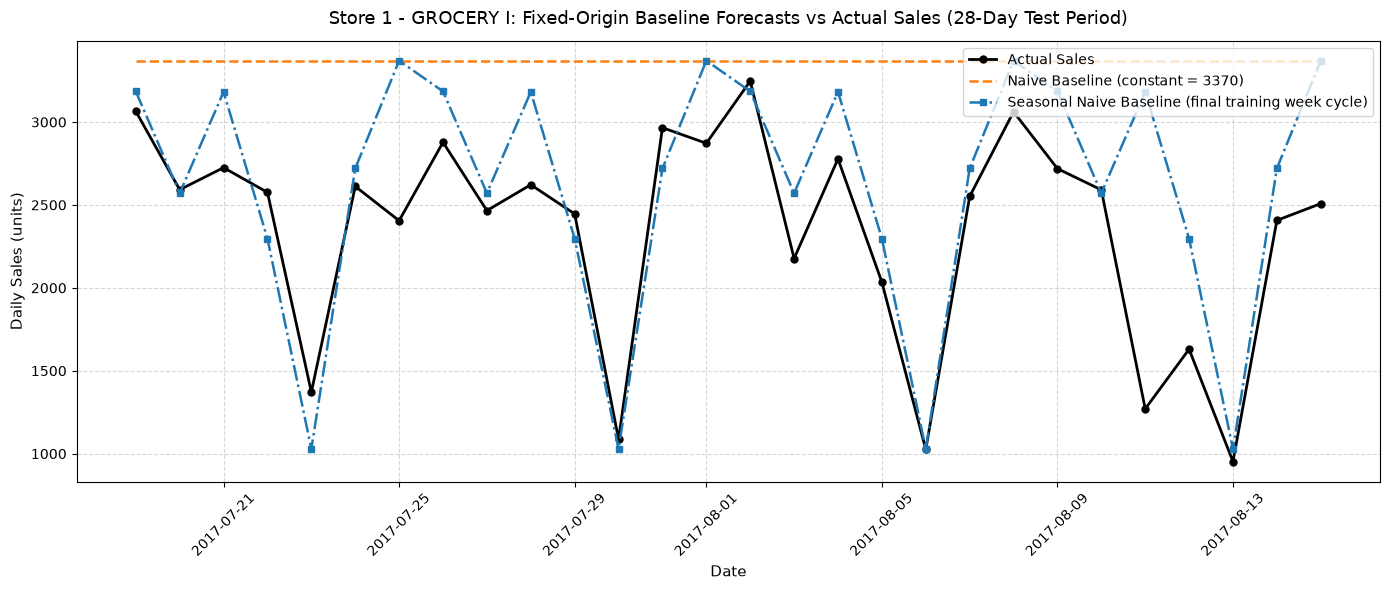

In [6]:
# Plot actual sales vs fixed-origin baseline predictions
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_df['date'], test_df['sales'], label='Actual Sales', color='black', linewidth=2, marker='o', markersize=5)
ax.plot(test_df['date'], test_df['naive_pred'], label=f'Naive Baseline (constant = {last_train_sales:.0f})', color='tab:orange', linestyle='--', linewidth=1.8)
ax.plot(test_df['date'], test_df['snaive_pred'], label='Seasonal Naive Baseline (final training week cycle)', color='tab:blue', linestyle='-.', linewidth=1.8, marker='s', markersize=4)

ax.set_title('Store 1 - GROCERY I: Fixed-Origin Baseline Forecasts vs Actual Sales (28-Day Test Period)', fontsize=13, pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily Sales (units)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visual Insights for Fixed-Origin Forecasts

- **Naive Baseline (Constant)**: Emits a flat constant prediction ($3,370.0$ units) based on Tuesday sales on `2017-07-18`. Because it cannot anticipate intra-week variations, it suffers large errors on lower-volume days (especially Sundays, where sales hover around ~1,000 units), resulting in an MAE of 1,025.96 units.
- **Seasonal Naive Baseline (Weekly Cycle)**: By repeating the final observed training week across the four 7-day test cycles, seasonal naive follows the actual peaks (Wednesdays) and troughs (Sundays) with remarkable consistency, reducing MAE to 361.96 units and MAPE to 18.01% without using any test-period data.

## 8. Export Baseline Results

We save the benchmark evaluation results to `outputs/baseline_results.csv`.

In [7]:
outputs_dir = '../outputs'
os.makedirs(outputs_dir, exist_ok=True)

output_file = os.path.join(outputs_dir, 'baseline_results.csv')
results_df.to_csv(output_file, index=False)

print(f"Results successfully saved to: {output_file}")
saved_check = pd.read_csv(output_file)
saved_check

Results successfully saved to: ../outputs/baseline_results.csv
Out[0]: 
            model      MAE     RMSE   MAPE
0           Naive  1025.96  1212.59  62.21
1  Seasonal Naive   361.96   527.63  18.01


,model,MAE,RMSE,MAPE
0,Naive,1025.96,1212.59,62.21
1,Seasonal Naive,361.96,527.63,18.01


## 9. Automated Validation Checks

We run strict automated verification checks to ensure the validity and integrity of the baseline forecasting stage.

In [8]:
print('Running fixed-origin baseline validation checks...')

# Check 1: Exactly 28 test rows
assert len(test_df) == 28, f"Check 1 Failed: Expected 28 test rows, got {len(test_df)}"
print("Check 1 PASSED: Test set has exactly 28 rows.")

# Check 2: Prediction dates exactly match the test dates
expected_dates = pd.date_range(start='2017-07-19', end='2017-08-15', freq='D')
assert (test_df['date'] == expected_dates).all(), "Check 2 Failed: Prediction dates do not match expected test dates."
print("Check 2 PASSED: Prediction dates exactly match expected 28 test dates.")

# Check 3: Every prediction source date is <= 2017-07-18
forecast_origin = pd.Timestamp('2017-07-18')
assert (test_df['naive_source_date'] <= forecast_origin).all(), "Check 3 Failed: Naive source date exceeds forecast origin!"
assert (test_df['snaive_source_date'] <= forecast_origin).all(), "Check 3 Failed: Seasonal naive source date exceeds forecast origin!"
print("Check 3 PASSED: Every prediction source date is <= 2017-07-18.")

# Check 4: No prediction source date falls inside the test period
test_start_date = pd.Timestamp('2017-07-19')
assert (test_df['naive_source_date'] < test_start_date).all(), "Check 4 Failed: Naive source date in test period!"
assert (test_df['snaive_source_date'] < test_start_date).all(), "Check 4 Failed: Seasonal naive source date in test period!"
print("Check 4 PASSED: No prediction source date falls inside the test period.")

# Check 5: Metrics are finite numbers
for col in ['MAE', 'RMSE', 'MAPE']:
    assert np.isfinite(results_df[col]).all(), f"Check 5 Failed: Non-finite metric found in {col}"
print("Check 5 PASSED: All reported metrics are finite.")

# Check 6: MAPE logic excludes actual == 0
dummy_actual = np.array([0.0, 100.0])
dummy_pred = np.array([50.0, 80.0])
dummy_mape = calculate_mape(dummy_actual, dummy_pred)
assert np.isclose(dummy_mape, 20.0), f"Check 6 Failed: calculate_mape did not filter zero actuals correctly (got {dummy_mape})"
print("Check 6 PASSED: MAPE function strictly excludes zero-sales observations.")

print("\nALL FIXED-ORIGIN BASELINE VALIDATION CHECKS PASSED SUCCESSFULLY!")

Running fixed-origin baseline validation checks...
Check 1 PASSED: Test set has exactly 28 rows.
Check 2 PASSED: Prediction dates exactly match expected 28 test dates.
Check 3 PASSED: Every prediction source date is <= 2017-07-18.
Check 4 PASSED: No prediction source date falls inside the test period.
Check 5 PASSED: All reported metrics are finite.
Check 6 PASSED: MAPE function strictly excludes zero-sales observations.

ALL FIXED-ORIGIN BASELINE VALIDATION CHECKS PASSED SUCCESSFULLY!
